# Phase 2 — EDA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_style("darkgrid")

sm = pd.read_csv("../data/cleaned/social_media_cleaned.csv")
teen = pd.read_csv("../data/cleaned/teen_mental_health_cleaned.csv")

In [4]:
sm.describe()

,student_id,age,gender,academic_level,country,avg_daily_usage_hours,most_used_platform,affects_academic_performance,sleep_hours_per_night,mental_health_score,overall_impact
count,1705.000000,1705.000000,1705.000000,1705.000000,1705.000000,1705.000000,1705.000000,1705.000000,1705.000000,1705.000000,1705.000000
mean,439.510264,20.848094,0.514956,1.052199,63.154252,4.630499,4.365982,0.592962,6.598710,6.215132,0.741935
std,267.058174,1.758557,0.499923,0.889544,27.493410,1.733950,3.500807,0.491426,1.207045,1.282678,0.881624
min,1.000000,18.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,3.800000,4.000000,0.000000
25%,214.000000,19.000000,0.000000,0.000000,39.000000,3.000000,1.000000,0.000000,5.600000,5.000000,0.000000
50%,427.000000,21.000000,1.000000,1.000000,73.000000,5.000000,5.000000,1.000000,6.600000,6.000000,0.000000
75%,640.000000,22.000000,1.000000,2.000000,73.000000,6.000000,6.000000,1.000000,7.500000,7.000000,2.000000
max,1000.000000,24.000000,1.000000,2.000000,110.000000,8.000000,11.000000,1.000000,9.600000,9.000000,2.000000


In [5]:
teen.describe()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,0.512500,4.098333,1.005833,6.449417,1.740333,2.990383,1.014500,1.039167,5.445833,5.636667,5.565000,0.025833
std,2.021947,0.500052,2.031117,0.811181,1.442677,0.716660,0.576758,0.582185,0.808194,2.903290,2.859453,2.830627,0.158704
min,13.000000,0.000000,1.000000,0.000000,4.000000,0.500000,2.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,0.000000,2.000000,0.000000,5.200000,1.100000,2.500000,0.500000,0.000000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,1.000000,4.000000,1.000000,6.500000,1.800000,2.990000,1.000000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,1.000000,6.000000,2.000000,7.600000,2.400000,3.480000,1.500000,2.000000,8.000000,8.000000,8.000000,0.000000
max,19.000000,1.000000,8.000000,2.000000,9.000000,3.000000,4.000000,2.000000,2.000000,10.000000,10.000000,10.000000,1.000000


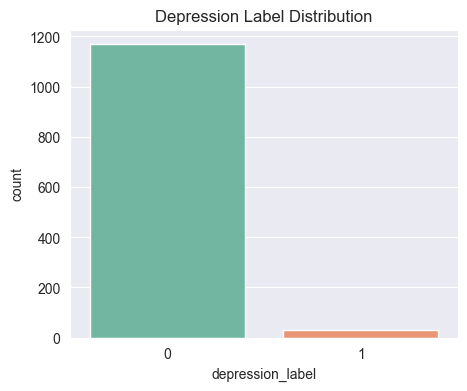

In [6]:
# Target Distribution (Depression Label)
plt.figure(figsize=(5,4))
sns.countplot(
    x='depression_label',
    data=teen,
    hue='depression_label',
    palette='Set2',
    legend=False
)
plt.title("Depression Label Distribution")
plt.savefig("../outputs/plots/depression_distribution.png")
plt.show()

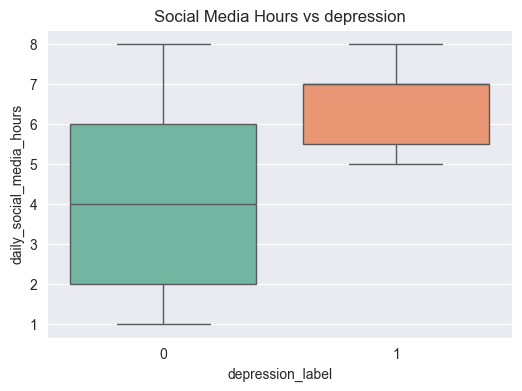

In [7]:
plt.figure(figsize=(6,4))
# sns.boxplot(x='depression_label', y='daily_social_media_hours', data=teen, palette='Set2')
sns.boxplot(
    x='depression_label',
    y='daily_social_media_hours',
    data=teen,
    hue='depression_label',
    palette='Set2',
    legend=False
)
plt.title("Social Media Hours vs depression")
plt.savefig("../outputs/plots/usage_vs_depression.png")
plt.show()

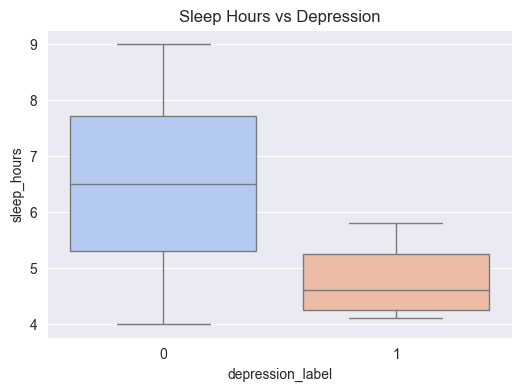

In [8]:
plt.figure(figsize=(6,4))
sns.boxplot(x='depression_label', y='sleep_hours', data=teen, hue='depression_label', palette='coolwarm', legend=False)
plt.title("Sleep Hours vs Depression")
plt.savefig("../outputs//plots/sleep_vs_depression.png")
plt.show()

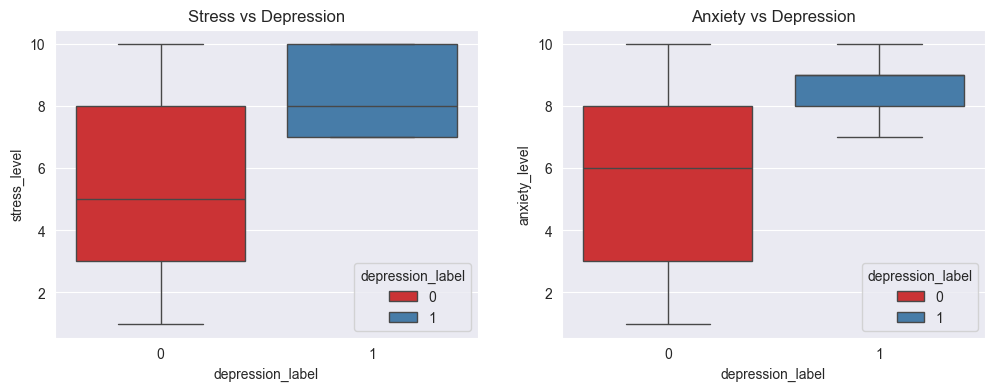

In [9]:
# Stress & Anxiety vs Depression
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(x='depression_label', y='stress_level', data=teen, ax=axes[0], hue='depression_label', palette='Set1')
axes[0].set_title("Stress vs Depression")
sns.boxplot(x='depression_label', y='anxiety_level', data=teen, ax=axes[1], hue='depression_label', palette='Set1')
axes[1].set_title("Anxiety vs Depression")
plt.savefig("../outputs/plots/stress_anxiety_depression.png")
plt.show()


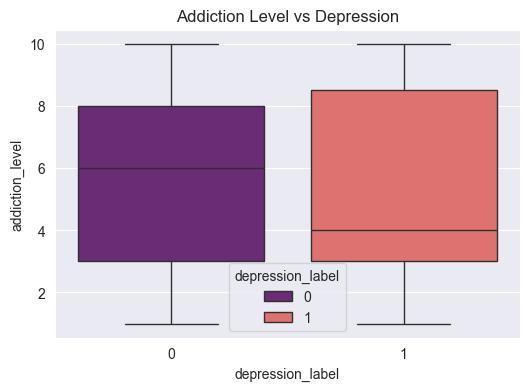

In [10]:
# Addiction Level vs Depression
plt.figure(figsize=(6,4))
sns.boxplot(x='depression_label', y='addiction_level', data=teen, hue='depression_label',palette='magma')
plt.title("Addiction Level vs Depression")
plt.savefig("../outputs/plots/addiction_vs_depression.png")
plt.show()

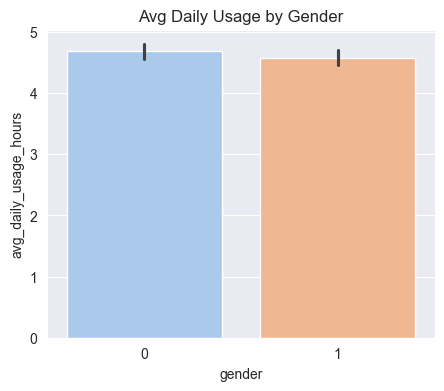

In [11]:
# Avg Daily Usage by Gender
plt.figure(figsize=(5,4))
sns.barplot(x='gender', y='avg_daily_usage_hours', data=sm,hue='gender',palette='pastel', legend=False)
plt.title("Avg Daily Usage by Gender")
plt.savefig("../outputs/plots/usage_by_gender.png")
plt.show()

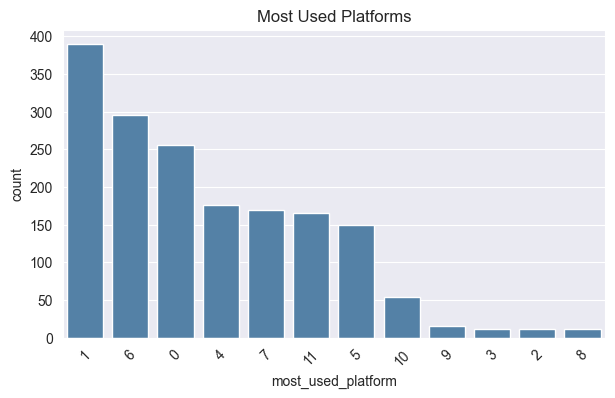

In [12]:
#  Platform Usage Count SM Dataset
plt.figure(figsize=(7,4))

order = sm['most_used_platform'].value_counts().index  # sort

sns.countplot(x='most_used_platform', data=sm, order=order, color='steelblue'
)
plt.title("Most Used Platforms")
plt.xticks(rotation=45)
plt.savefig("../outputs/plots/platform_usage.png")
plt.show()

In [13]:
sm['most_used_platform'].value_counts().head(1)

most_used_platform
1    389
Name: count, dtype: int64

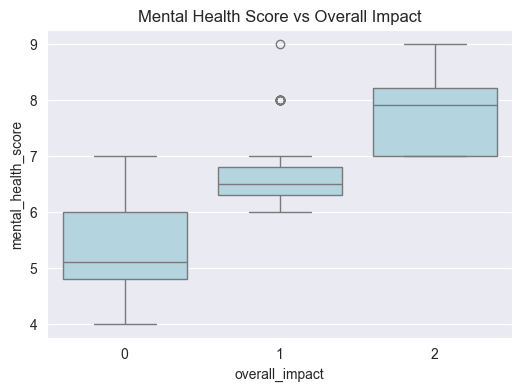

In [14]:
# Mental Health Score vs Overall Impact (SM Dataset)
plt.figure(figsize=(6,4))
sns.boxplot(
    x='overall_impact',
    y='mental_health_score',
    data=sm,
    color='lightblue'   # just replace palette
)
plt.title("Mental Health Score vs Overall Impact")
plt.savefig("../outputs/plots/mentalhealth_vs_impact.png")
plt.show()

* Higher impact → better mental health

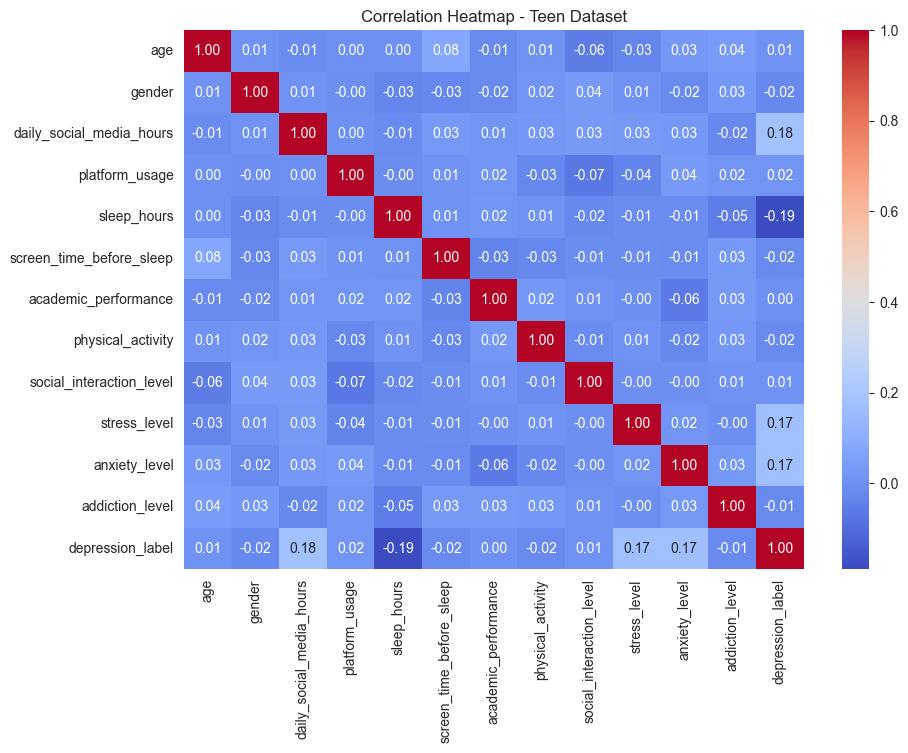

In [15]:
plt.figure(figsize=(10,7))
sns.heatmap(teen.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap - Teen Dataset")
plt.savefig("../outputs/plots/correlation_teen.png")
plt.show()

* * More social media usage, stress, and anxiety - slightly higher chance of depression

* * More sleep - lower depression (important insight)

The correlation analysis shows that sleep duration has a negative relationship with depression, while social media usage, stress, and anxiety show weak positive correlations. However, the overall low correlation values suggest that depression is influenced by multiple factors rather than a single dominant feature.

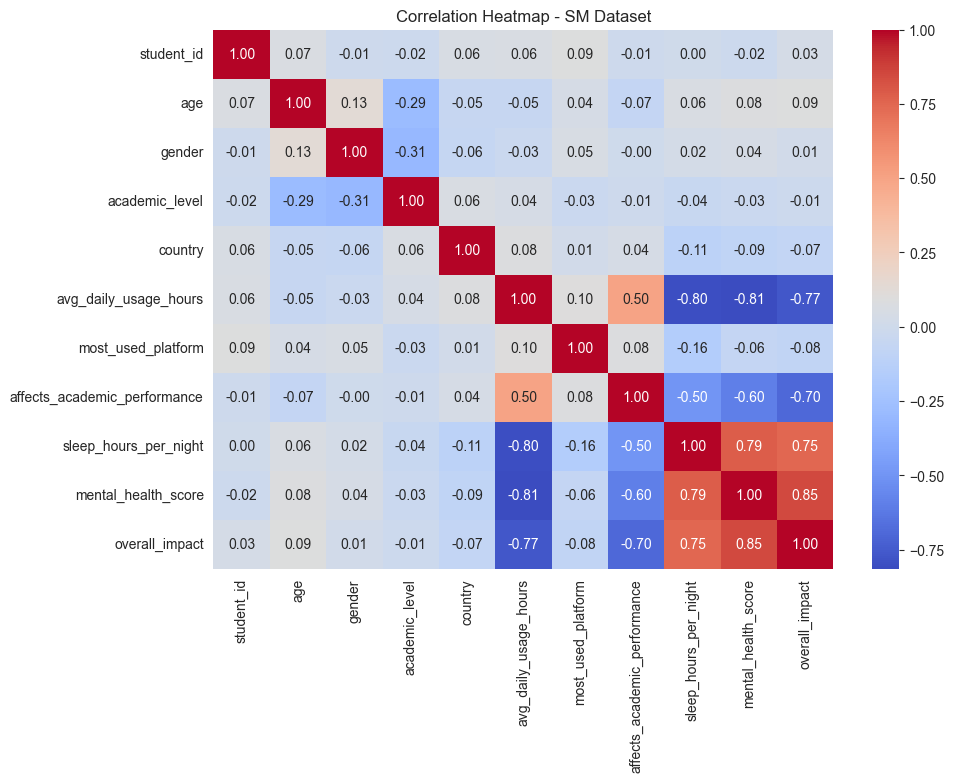

In [16]:
plt.figure(figsize=(10,7))
sns.heatmap(sm.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap - SM Dataset")
plt.savefig("../outputs/plots/correlation_sm.png")
plt.show()

```json
1. Mental Health Core Relationships
mental_health_score - overall_impact → +0.85 (very strong)
 Better mental health = more positive overall impact
sleep_hours_per_night - mental_health_score → +0.79
 More sleep = better mental health
```

```json
2.  Social Media Usage Impact
    avg_daily_usage_hours ↔ mental_health_score → -0.81
    avg_daily_usage_hours ↔ overall_impact → -0.77

 More social media usage = worse mental health + negative impact
```